In [27]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [28]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data (optional, but recommended)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Print shapes of the data
print(f'Train data shape: {x_train.shape}, Train labels shape: {y_train.shape}')
print(f'Test data shape: {x_test.shape}, Test labels shape: {y_test.shape}')

Train data shape: (60000, 28, 28), Train labels shape: (60000,)
Test data shape: (10000, 28, 28), Test labels shape: (10000,)


### My Implementation
This model architecture is:
1) CNN Layer with 64 filters, 3x3 kernel size, batch normalization and pooling(2x2) and relu activation function.
2) CNN Layer with 128 filters, 3x3 kernel size, batch normalization and pooling(2x2) and relu activation function.
3) Dense layer (size 64) with relu activation function.

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 26, 26, 64)        640       
                                                                 
 batch_normalization_18 (Ba  (None, 26, 26, 64)        256       
 tchNormalization)                                               
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 13, 13, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_19 (Conv2D)          (None, 11, 11, 128)       73856     
                                                                 
 batch_normalization_19 (Ba  (None, 11, 11, 128)       512       
 tchNormalization)                                               
                                                      

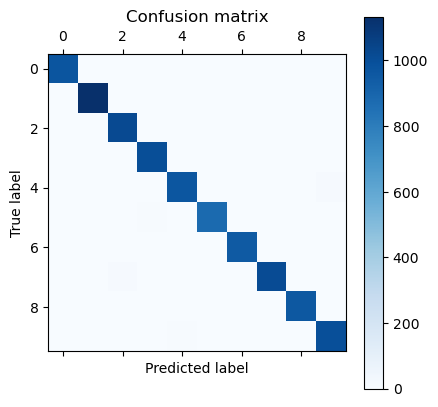

In [29]:
# Create a sequential model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
    tf.keras.layers.BatchNormalization(),  
    tf.keras.layers.MaxPooling2D((2, 2)),  
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
    tf.keras.layers.BatchNormalization(),  
    tf.keras.layers.MaxPooling2D((2, 2)), 
    tf.keras.layers.Flatten(),  
    tf.keras.layers.Dense(64, activation='relu'), 
    tf.keras.layers.Dropout(0.5),  
    tf.keras.layers.Dense(10, activation='softmax') 
])

# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
model.fit(x_train, y_train, epochs=100,callbacks=[early_stopping], validation_split=0.2)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')


# Confusion MAtrix
y_pred = np.argmax(model.predict(x_test), axis=-1)
cm = confusion_matrix(y_test, y_pred)
plt.matshow(cm, cmap='Blues')

plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


## Models Best Models from Literature

[Link to Kaggle 99.6\%](https://www.kaggle.com/code/paulbacher/mnist-99-6-accuracy-top-10-leaderboard/comments)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [31]:
# Data generator
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [32]:
inputs = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu')(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(filters=32, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(filters=64, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Conv2D(filters=128, kernel_size=4, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_20 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 batch_normalization_20 (Ba  (None, 26, 26, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_21 (Conv2D)          (None, 24, 24, 32)        9248      
                                                                 
 batch_normalization_21 (Ba  (None, 24, 24, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_22 (Conv2D)          (None, 12, 12, 32)        2563

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']   
)

# Convert labels to one-hot encoded format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

x_train = x_train.reshape(-1, 28, 28, 1)

history = model.fit_generator(
    datagen.flow(x_train, y_train, batch_size=64),
    validation_data=(x_test, y_test),
    epochs=50,
    callbacks=[
        tf.keras.callbacks.LearningRateScheduler(
            lambda x: 1e-3 * 0.95 ** x, verbose=0
        )
    ]
)

Epoch 1/50


C:\Users\patri\AppData\Local\Temp\ipykernel_18012\1449129552.py:13: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


938/938 [==============================] - 21s 21ms/step - loss: 0.3482 - accuracy: 0.8934 - val_loss: 0.0582 - val_accuracy: 0.9811 - lr: 0.0010
Epoch 2/50
938/938 [==============================] - 19s 20ms/step - loss: 0.1067 - accuracy: 0.9688 - val_loss: 0.0294 - val_accuracy: 0.9911 - lr: 9.5000e-04
Epoch 3/50
938/938 [==============================] - 19s 20ms/step - loss: 0.0812 - accuracy: 0.9753 - val_loss: 0.0271 - val_accuracy: 0.9903 - lr: 9.0250e-04
Epoch 4/50
938/938 [==============================] - 19s 20ms/step - loss: 0.0691 - accuracy: 0.9792 - val_loss: 0.0306 - val_accuracy: 0.9902 - lr: 8.5737e-04
Epoch 5/50
938/938 [==============================] - 19s 20ms/step - loss: 0.0604 - accuracy: 0.9821 - val_loss: 0.0196 - val_accuracy: 0.9935 - lr: 8.1451e-04
Epoch 6/50
938/938 [==============================] - 19s 21ms/step - loss: 0.0550 - accuracy: 0.9836 - val_loss: 0.0165 - val_accuracy: 0.9949 - lr: 7.7378e-04
Epoch 7/50
938/938 [=============================

313/313 [==============================] - 1s 5ms/step


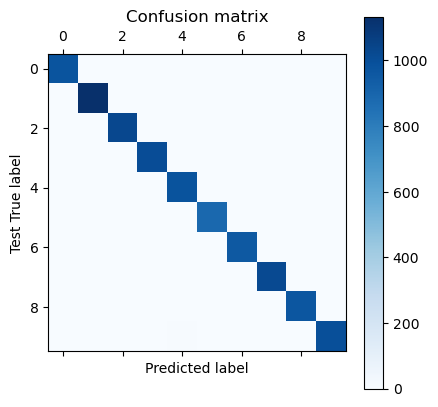

1875/1875 [==============================] - 8s 4ms/step


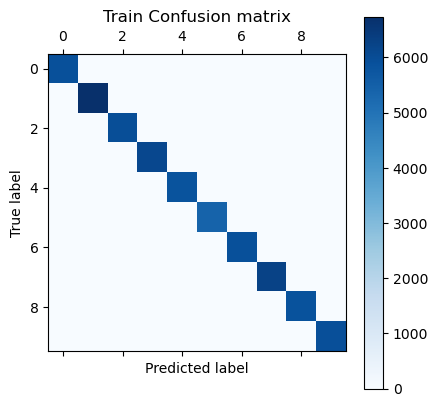

In [37]:
# Confusion matrix
y_pred = np.argmax(model.predict(x_test), axis=-1)
cm = confusion_matrix(np.argmax(y_test, axis=-1), y_pred)
plt.matshow(cm, cmap='Blues')
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('Test True label')
plt.xlabel('Predicted label')
plt.show()

# Train confusion matrix
y_pred = np.argmax(model.predict(x_train), axis=-1)
cm = confusion_matrix(np.argmax(y_train, axis=-1), y_pred)
plt.matshow(cm, cmap='Blues')
plt.title('Train Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()




The difference between my implementation and this one, is that this one uses synthetic data generation,a different model architecture, and a learning rate scheduler. It also uses categorical cross entropy instead of sparse categorical cross entropy, although I do not believe that this will effect model convergence. There are also no pooling layers compared to my implementation. The initial thought is that these do not reduce the number of features available to this model, as comparison to my implementation. This allows for more features to draw upon during inference, which may be correlated to the higher accuracy present in this dataset. Additionally, this implementation used less epochs, NO early stopping criteria, and a different train-test split compared to the imported tensorflow set. Allocation of more training data compared to validation can also attribute to the success of this implementation